Based on previous experiments, the final selected model is Custom CNN with dropout and early stopping.

This notebook contains the final training pipeline used to train and save the best version of this model.

 You can find the notebook from the experiment in the folder `archive/fashion-mnist-cnn-vs-vgg16-2.ipynb` or at the following URL:  https://www.kaggle.com/code/patrycjagociniak/fashion-mnist-cnn-vs-vgg16/notebook


In [48]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import  DataLoader
from sklearn.metrics import confusion_matrix

import sys
from pathlib import Path

PROJECT_ROOT = Path("..")
sys.path.append(str(PROJECT_ROOT))

from app.ml.dataset import FashionMNISTCSV
from app.ml.preprocessing import calculate_mean_std, get_cnn_transform
from app.ml.training import train_model

In [49]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [51]:
train_data = pd.read_csv("../data/train_data.csv")
val_data = pd.read_csv("../data/val_data.csv")
test_data = pd.read_csv("../data/test_data.csv")

In [52]:
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.3
NUM_CLASSES = 10

In [53]:
fashion_mnist_mean, fashion_mnist_std = calculate_mean_std(train_data)

transform_cnn = get_cnn_transform(
    fashion_mnist_mean,
    fashion_mnist_std
)

In [54]:
train_dataset_cnn = FashionMNISTCSV(train_data, transform=transform_cnn)
val_dataset_cnn = FashionMNISTCSV(val_data, transform=transform_cnn)
test_dataset_cnn = FashionMNISTCSV(test_data, transform=transform_cnn)

In [55]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader_cnn = DataLoader(
    train_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g
)

val_loader_cnn = DataLoader(
    val_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=g
)

test_loader_cnn = DataLoader(
    test_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=g
)

In [56]:
model = CustomCNN_1(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
).to(device)

In [57]:
set_seed(SEED)

model_1 = CustomCNN_1(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_1 = torch.optim.Adam(
    model_1.parameters(),
    lr=LEARNING_RATE
)

model_1, history_model_1 = train_model(
    model=model_1,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion,
    optimizer=optimizer_1,
    device=device,
    epochs=EPOCHS
)

history_model_1

Epoch 1/15 | Train loss: 0.4694 | Train acc: 0.8399 | Val loss: 0.2978 | Val acc: 0.8928
Epoch 2/15 | Train loss: 0.2900 | Train acc: 0.8971 | Val loss: 0.2747 | Val acc: 0.8981
Epoch 3/15 | Train loss: 0.2416 | Train acc: 0.9125 | Val loss: 0.2500 | Val acc: 0.9113
Epoch 4/15 | Train loss: 0.2092 | Train acc: 0.9261 | Val loss: 0.2287 | Val acc: 0.9167
Epoch 5/15 | Train loss: 0.1830 | Train acc: 0.9343 | Val loss: 0.2222 | Val acc: 0.9206
Epoch 6/15 | Train loss: 0.1628 | Train acc: 0.9425 | Val loss: 0.2205 | Val acc: 0.9217
Epoch 7/15 | Train loss: 0.1424 | Train acc: 0.9491 | Val loss: 0.2268 | Val acc: 0.9194
Epoch 8/15 | Train loss: 0.1274 | Train acc: 0.9551 | Val loss: 0.2222 | Val acc: 0.9201
Epoch 9/15 | Train loss: 0.1100 | Train acc: 0.9622 | Val loss: 0.2299 | Val acc: 0.9187
Epoch 10/15 | Train loss: 0.0962 | Train acc: 0.9666 | Val loss: 0.2298 | Val acc: 0.9192
Epoch 11/15 | Train loss: 0.0852 | Train acc: 0.9709 | Val loss: 0.2337 | Val acc: 0.9224
Epoch 12/15 | Train

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.469398,0.839854,0.297833,0.892833
1,2,0.289960,0.897104,0.274669,0.898083
2,3,0.241620,0.912521,0.250016,0.911250
3,4,0.209203,0.926146,0.228734,0.916750
4,5,0.183042,0.934333,0.222211,0.920583
5,6,0.162774,0.942542,0.220540,0.921667
6,7,0.142375,0.949063,0.226771,0.919417
7,8,0.127434,0.955146,0.222151,0.920083
8,9,0.110012,0.962167,0.229898,0.918750
9,10,0.096216,0.966583,0.229849,0.919167


In [58]:
best_custom_cnn = model_1

torch.save(
    best_custom_cnn.state_dict(),
    "../models/best_custom_cnn.pth"
)

print("Final selected Custom CNN model saved as best_custom_cnn.pth")

Final selected Custom CNN model saved as best_custom_cnn.pth


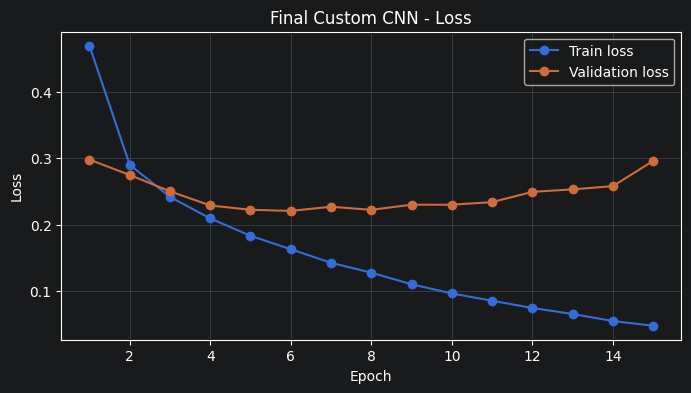

In [59]:
# Loss curve

plt.figure(figsize=(8, 4))

plt.plot(history_model_1["epoch"], history_model_1["train_loss"], marker="o", label="Train loss")
plt.plot(history_model_1["epoch"], history_model_1["val_loss"], marker="o", label="Validation loss")

plt.title("Final Custom CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

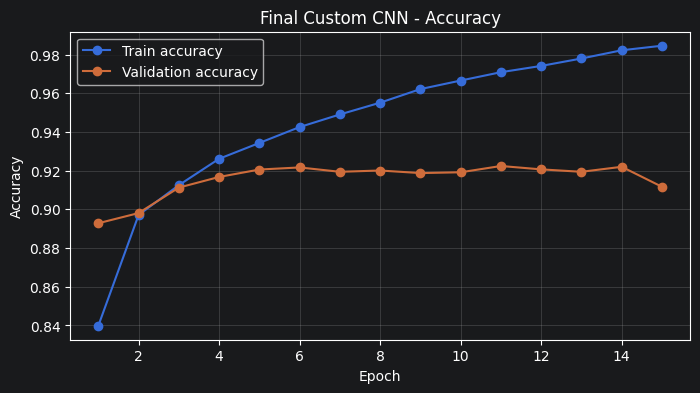

In [60]:
# Accuracy curve

plt.figure(figsize=(8, 4))

plt.plot(history_model_1["epoch"], history_model_1["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(history_model_1["epoch"], history_model_1["val_accuracy"], marker="o", label="Validation accuracy")

plt.title("Final Custom CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [61]:
# Final evaluation of the best custom CNN model on the test set

best_custom_cnn = model_1

best_custom_cnn.eval()

test_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_cnn:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_custom_cnn(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Test loss: 0.3005
Test accuracy: 0.9137


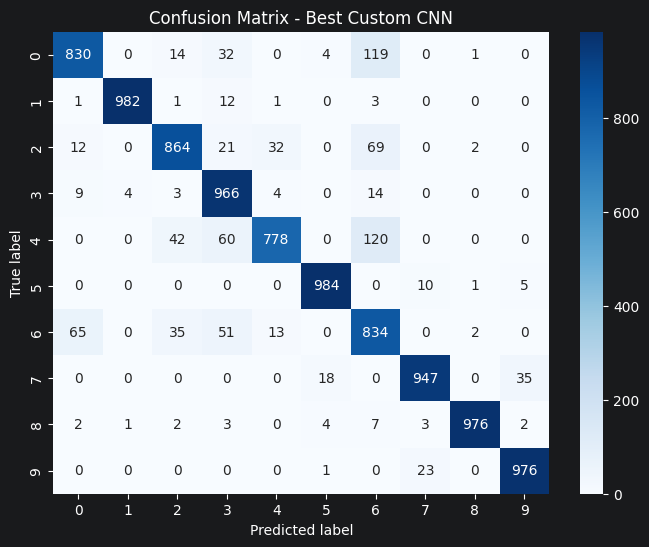

In [62]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Custom CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

In [63]:
# Save final test results

final_results = pd.DataFrame({
    "model": ["CustomCNN_1"],
    "test_loss": [test_loss],
    "test_accuracy": [test_accuracy],
    "model_path": ["../models/best_custom_cnn.pth"]
})

final_results.to_csv("../data/final_model_results.csv", index=False)

final_results

,model,test_loss,test_accuracy,model_path
0,CustomCNN_1,0.300524,0.9137,../models/best_custom_cnn.pth


In [64]:
# Save confusion matrix

cm_df = pd.DataFrame(cm)

cm_df.to_csv("../data/confusion_matrix.csv", index=False)

cm_df

,0,1,2,3,4,5,6,7,8,9
0,830,0,14,32,0,4,119,0,1,0
1,1,982,1,12,1,0,3,0,0,0
2,12,0,864,21,32,0,69,0,2,0
3,9,4,3,966,4,0,14,0,0,0
4,0,0,42,60,778,0,120,0,0,0
5,0,0,0,0,0,984,0,10,1,5
6,65,0,35,51,13,0,834,0,2,0
7,0,0,0,0,0,18,0,947,0,35
8,2,1,2,3,0,4,7,3,976,2
9,0,0,0,0,0,1,0,23,0,976
